# Global data loading and preprocessing

In [ ]:
import os

file_name = "bird_CUB_200_2011.zip"

if os.path.exists(file_name):
  print("File Exists, beginnning unzip")
  !unzip "bird_CUB_200_2011.zip"
  print("File unzipped")
else:
  print("File not found, please upload into session")

Streaming output truncated to the last 5000 lines.
  inflating: CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0068_113247.jpg  
  inflating: CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0073_112745.jpg  
  inflating: CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0074_111997.jpg  
  inflating: CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0079_113288.jpg  
  inflating: CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0080_111099.jpg  
  inflating: CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0082_112478.jpg  
  inflating: CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0083_111470.jpg  
  inflating: CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0084_111300.jpg  
  inflating: CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0086_111385.jpg  
  inflating: CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0092_111413.jpg  
  inflating: CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0093_110990.jpg  
  inflating: CUB_200_2011/images/118

In [ ]:
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt
import shutil

MODEL1_SEED = 13132

In [ ]:
def testset_extraction_and_storage(img_directory, train_test_split_list, file_path):
  test_dir = "/content/" + file_path + "/test_images"

  with open(train_test_split_list, 'r') as f:
    split_list = [int(line.strip().split()[1]) for line in f]

  os.makedirs(test_dir, exist_ok=True)

  gl_index = 0

  for class_name in os.listdir(img_directory):
    class_path = os.path.join(img_directory, class_name)
    if not os.path.isdir(class_path):
      continue

    test_class_path = os.path.join(test_dir, class_name)
    os.makedirs(test_class_path, exist_ok=True)

    for filename in os.listdir(class_path):
      if not filename.lower().endswith((".jpg", "jpeg", "png")):
        continue

      if gl_index > len(split_list):
        raise ValueError("The number of values in the test train split file exceeds the number of images")

      is_train = split_list[gl_index]

      if is_train == 0:
        src = os.path.join(class_path, filename)
        dst = os.path.join(test_class_path, filename)
        shutil.move(src, dst)

      gl_index += 1

  return test_dir

In [ ]:
unzipped_file_name = "CUB_200_2011"
img_directory = os.path.join("/content", unzipped_file_name, "images")
split_file = os.path.join("/content", unzipped_file_name, "train_test_split.txt")

if os.path.exists(img_directory):
  print("Images found, spliting train and test sets...")
  test_img_dir = testset_extraction_and_storage(img_directory, split_file, unzipped_file_name)

  print("Loading datasets from images...")
  training_tf, validation_tf = keras.utils.image_dataset_from_directory(
      directory=img_directory,
      labels="inferred",
      label_mode="categorical",
      batch_size=None,
      validation_split=0.1,
      seed=MODEL1_SEED,
      subset="both"
  )

  testing_tf = keras.utils.image_dataset_from_directory(
      directory=test_img_dir,
      labels="inferred",
      label_mode="categorical",
      batch_size=None,
  )
  print("Loaded images into training, validation and testing datasets!")
else:
  print("No Images found")

Images found, spliting train and test sets...
Loading datasets from images...
Found 5994 files belonging to 200 classes.
Using 5395 files for training.
Using 599 files for validation.
Found 5794 files belonging to 200 classes.
Loaded images into training, validation and testing datasets!


In [ ]:
resize_img = keras.layers.Resizing(150, 150)

training_ds = training_tf.map(lambda x, y: (resize_img(x),y))
validation_ds = validation_tf.map(lambda x, y: (resize_img(x),y))
testing_ds = testing_tf.map(lambda x, y: (resize_img(x),y))

In [ ]:
augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
]

def data_augmentation(x):
  for layer in augmentation_layers:
    x = layer(x)
  return x

train_ds = training_ds.map(lambda x, y: (data_augmentation(x), y))

print(f"Number of training samples: {train_ds.cardinality()}")
print(f"Number of validation samples: {validation_ds.cardinality()}")
print(f"Number of test samples: {testing_ds.cardinality()}")

Number of training samples: 5395
Number of validation samples: 599
Number of test samples: 5794


In [ ]:
from tensorflow import data as tf_data

batch_size = 64

train_ds = train_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
validation_ds = validation_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
test_ds = testing_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()

# Model 1: Fine-Tune classification via pre-trained Inception model

## Build Base Model

InceptionV3 attempted (not good enough)
Found - https://medium.com/@karandeepdps/alexnet-vggnet-resnet-and-inception-11880a1ed3cd

Models attempted:
EfficientNet0
EfficientNet4
EfficientNet7
EfficientNetV2B0
EfficientNetV2B3

parameters attempted:
0.2, 0.3, 0.5 Dropout
2, 3, 4 Augmentations
1e-5, 1e-6, 1e-8 Learning rate

used - https://keras.io/guides/transfer_learning/


In [ ]:
base_model = keras.applications.EfficientNetV2B3(
    weights="imagenet",
    input_shape=(150,150,3),
    include_top=False
)

# Freezing the base model
base_model.trainable = False

# Create a new model
inputs = keras.Input(shape=(150,150,3))

# Keras requires inputs for InceptionV3 to be scaled between 1 to -1
# Currently images are 0-255, rescaling needed
#scale_layer = keras.layers.Rescaling(scale=1/127.5, offset=-1)
#x = scale_layer(inputs)

# This our model without fine-tuning, we want to keep the pre-trained model in inference mode
x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(200)(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable=True)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_13 (InputLayer) │ (None, 150, 150, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetv2-b3           │ (None, 5, 5, 1536)    │ 12,930,622 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_7  │ (None, 1536)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_7 (Dropout)         │ (None, 1536)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_7 (Dense)             │ (None, 200)           │    307,400 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 13,238,022 (50.50 MB)

 Trainable params: 307,400 (1.17 MB)

 Non-trainable params: 12,930,622 (49.33 MB)

## Train Top Layers

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.CategoricalAccuracy()]
)

epochs = 25
print("Fitting the model")
model.fit(train_ds, epochs=epochs, validation_data=validation_ds)

Fitting the model
Epoch 1/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 71s 441ms/step - categorical_accuracy: 0.0344 - loss: 5.1608 - val_categorical_accuracy: 0.2187 - val_loss: 3.8513
Epoch 2/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - categorical_accuracy: 0.2755 - loss: 3.5738 - val_categorical_accuracy: 0.3038 - val_loss: 3.1280
Epoch 3/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - categorical_accuracy: 0.3926 - loss: 2.8520 - val_categorical_accuracy: 0.3573 - val_loss: 2.7551
Epoch 4/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - categorical_accuracy: 0.4703 - loss: 2.4134 - val_categorical_accuracy: 0.3907 - val_loss: 2.5345
Epoch 5/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - categorical_accuracy: 0.5413 - loss: 2.1156 - val_categorical_accuracy: 0.4157 - val_loss: 2.3854
Epoch 6/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - categorical_accuracy: 0.5887 - loss: 1.8943 - val_categorical_accuracy: 0.4374 - val_loss: 2.2753
Epoch 7/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - categorical_accuracy:

## Fine-tune with base model

In [ ]:
base_model.trainable = True
model.summary(show_trainable=True)

callbacks = [keras.callbacks.ModelCheckpoint("model1_save_at_{epoch}.keras")]

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.CategoricalAccuracy()]
)

epochs = 30

print("Fitting the model with early stopping")
model.fit(train_ds, epochs=epochs, callbacks=callbacks, validation_data=validation_ds)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_13 (InputLayer) │ (None, 150, 150, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetv2-b3           │ (None, 5, 5, 1536)    │ 12,930,622 │   Y   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_7  │ (None, 1536)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_7 (Dropout)         │ (None, 1536)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_7 (Dense)             │ (None, 200)           │    307,400 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 13,852,824 (52.84 MB)

 Trainable params: 13,128,806 (50.08 MB)

 Non-trainable params: 109,216 (426.62 KB)

 Optimizer params: 614,802 (2.35 MB)

Fitting the model with early stopping
Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - categorical_accuracy: 0.2898 - loss: 3.1630 - val_categorical_accuracy: 0.3322 - val_loss: 2.9264
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 270ms/step - categorical_accuracy: 0.3835 - loss: 2.6413 - val_categorical_accuracy: 0.3673 - val_loss: 2.7447
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 261ms/step - categorical_accuracy: 0.4396 - loss: 2.3349 - val_categorical_accuracy: 0.3940 - val_loss: 2.5971
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 249ms/step - categorical_accuracy: 0.5105 - loss: 2.0128 - val_categorical_accuracy: 0.4040 - val_loss: 2.4889
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 260ms/step - categorical_accuracy: 0.5432 - loss: 1.8696 - val_categorical_accuracy: 0.4207 - val_loss: 2.4010
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 268ms/step - categorical_accuracy: 0.5908 - loss: 1.6696 - val_categorical_accuracy: 0.4240 - val_loss: 2.3346
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 253m

## Evaluate model

91/91 ━━━━━━━━━━━━━━━━━━━━ 20s 216ms/step - categorical_accuracy: 0.5985 - loss: 1.5745
Test Loss: 1.6100
Test Accuracy: 0.5915
91/91 ━━━━━━━━━━━━━━━━━━━━ 23s 152ms/step

Classification Report:
              precision    recall  f1-score   support

     class_0       0.71      0.74      0.73        27
     class_1       0.64      0.79      0.71        29
     class_2       0.71      0.59      0.64        29
     class_3       0.88      0.77      0.82        30
     class_4       0.85      0.74      0.79        23
     class_5       1.00      0.65      0.79        26
     class_6       0.75      0.96      0.84        25
     class_7       0.65      0.68      0.67        22
     class_8       0.42      0.37      0.39        30
     class_9       0.89      0.81      0.85        31
    class_10       0.45      0.41      0.43        32
    class_11       0.89      0.93      0.91        27
    class_12       0.85      0.88      0.87        26
    class_13       0.66      0.84      0.74      

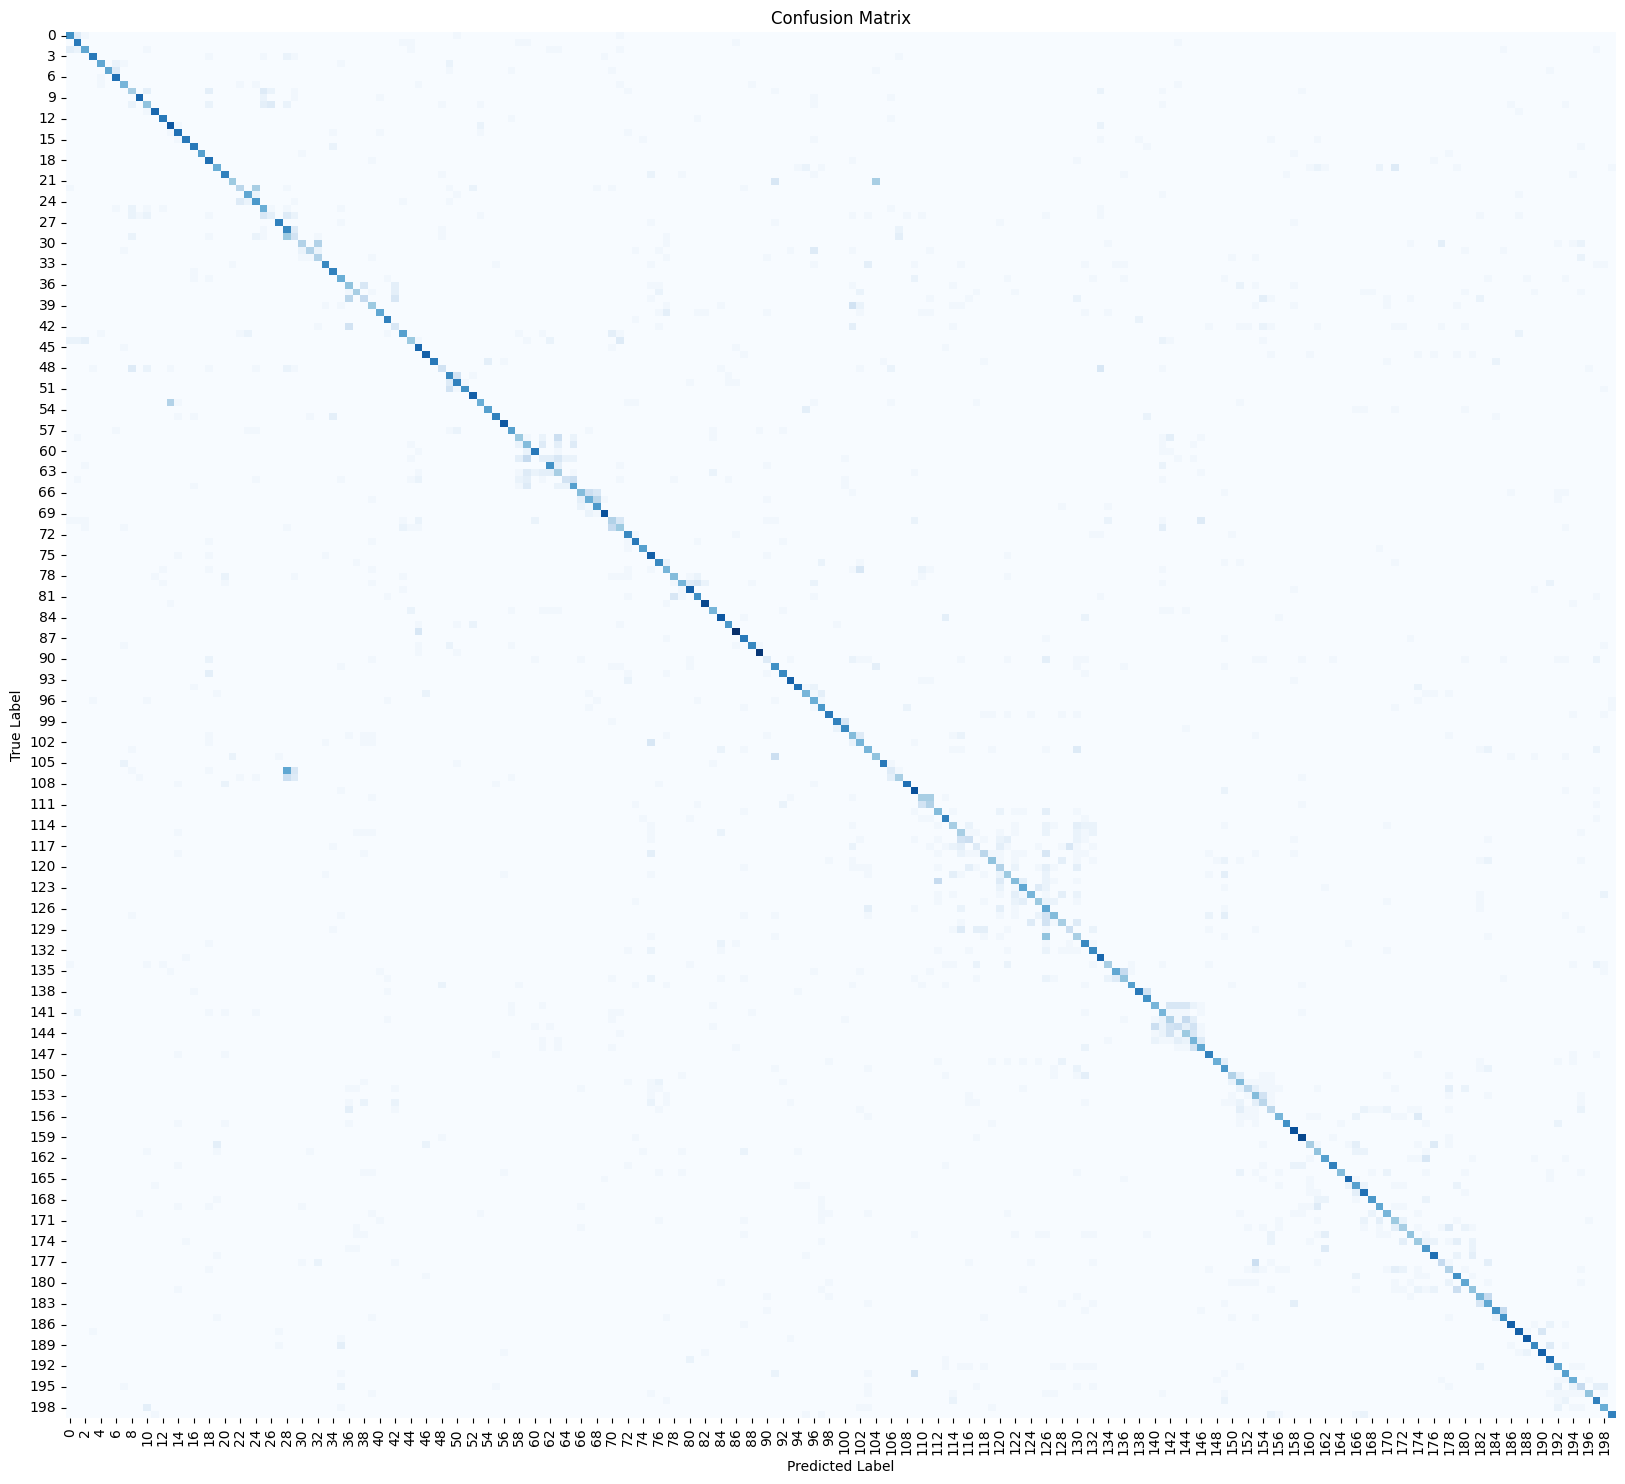

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions on the test dataset
predictions = model.predict(test_ds)
y_pred = np.argmax(predictions, axis=1)

# Extract true labels from the test dataset
y_true = []
for _, labels in test_ds.unbatch():
    y_true.append(np.argmax(labels.numpy()))
y_true = np.array(y_true)

# Generate classification report
class_names = [f"class_{i}" for i in range(200)] # Assuming 200 classes
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Generate and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Test for demo

In [9]:
import keras
import os
import numpy as np
import tensorflow as tf
from tensorflow import data as tf_data
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the pre-trained model
model = keras.models.load_model("model1_save_at_30.keras")
print("Model 'model1_save_at_30.keras' loaded successfully.")

# 2. Open the file `classes.txt` and read each line to create a list named `class_list`
with open("classes.txt", 'r') as f:
  class_list = [line.strip().split()[1] for line in f] # This is the global list of 200 classes
NUM_CLASSES = len(class_list) # Should be 200
print(f"Loaded {NUM_CLASSES} classes from classes.txt.")

# 3. Prompt the user for the directory name containing the images for prediction
new_image_directory_input = input("Please provide the file name directory containing the images for prediction: ")

# 4. Construct the full path to the new image directory
new_image_directory = os.path.join("/content", new_image_directory_input)

# 5. Check if a zipped file exists and unzip, or if the directory already exists
zips_path = f"{new_image_directory}.zip"
if os.path.exists(zips_path):
  print(f"Zipped file found: {zips_path}. Unzipping...")
  !unzip "{zips_path}"
  print(f"Image directory set to: {new_image_directory}")
elif os.path.exists(new_image_directory):
  print(f"Image directory already unzipped: {new_image_directory}")
else:
  raise ValueError("Image directory or zip file not found")

# 6. Load the raw image dataset
new_img_ds_raw = keras.utils.image_dataset_from_directory(
    directory=new_image_directory,
    labels="inferred",
    label_mode="categorical",
    batch_size=None
)
print(f"Raw image dataset loaded from {new_image_directory}.")

Model 'model1_save_at_30.keras' loaded successfully.
Loaded 200 classes from classes.txt.
Please provide the file name directory containing the images for prediction: Demo_test_images
Zipped file found: /content/Demo_test_images.zip. Unzipping...
Archive:  /content/Demo_test_images.zip
replace Demo_test_images/001.Black_footed_Albatross/Black_Footed_Albatross_0033_796086.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Image directory set to: /content/Demo_test_images
Found 6 files belonging to 3 classes.
Raw image dataset loaded from /content/Demo_test_images.


In [10]:
# Redefine resize_img layer to ensure it's available in this scope
resize_img = keras.layers.Resizing(150, 150)

# 1. Create a dictionary named `global_class_name_to_idx`
global_class_name_to_idx = {name: i for i, name in enumerate(class_list)}
print("Global class name to index mapping created.")

# 2. Initialize two empty Python lists
resized_images = []
y_true_global_idx = []

# 3. Get the list of class names inferred from the new_img_ds_raw dataset
inferred_class_names = new_img_ds_raw.class_names
print(f"Inferred class names from dataset: {inferred_class_names}")

# 4. Iterate through each image, label pair in new_img_ds_raw
for image, label in new_img_ds_raw:
    # 5. Resize the image and append it to the resized_images list
    resized_images.append(resize_img(image).numpy())

    # 6. For each label, find its integer index
    inferred_idx = np.argmax(label.numpy())

    # 7. Use this index to get the inferred_class_name
    inferred_name = inferred_class_names[inferred_idx]

    # 8. Look up the inferred_class_name in the global_class_name_to_idx dictionary
    global_idx = global_class_name_to_idx[inferred_name]

    # 9. Append this global integer index to the y_true_global_idx list
    y_true_global_idx.append(global_idx)

print(f"Processed {len(resized_images)} images. Resized images and global true labels collected.")
print(f"Number of resized images: {len(resized_images)}")
print(f"Number of global true labels: {len(y_true_global_idx)}")

Global class name to index mapping created.
Inferred class names from dataset: ['001.Black_footed_Albatross', '017.Cardinal', '030.Fish_Crow']
Processed 6 images. Resized images and global true labels collected.
Number of resized images: 6
Number of global true labels: 6


In [11]:
# Convert lists to NumPy arrays
images_array = np.array(resized_images)
y_true_global_idx_array = np.array(y_true_global_idx)

print(f"Shape of images_array: {images_array.shape}")
print(f"Shape of y_true_global_idx_array: {y_true_global_idx_array.shape}")

# One-hot encode the global integer labels
y_true_one_hot = tf.one_hot(y_true_global_idx_array, depth=NUM_CLASSES)

print(f"Shape of y_true_one_hot: {y_true_one_hot.shape}")

# Create a new tf.data.Dataset
new_img_ds = tf.data.Dataset.from_tensor_slices((images_array, y_true_one_hot))

# Batch, prefetch, and cache the new dataset for evaluation
BATCH_SIZE = 64 # Using the same batch size as earlier cells
new_img_ds_batched = new_img_ds.batch(BATCH_SIZE).prefetch(tf_data.AUTOTUNE).cache()

print(f"Created batched dataset with {new_img_ds_batched.cardinality().numpy()} batches.")

Shape of images_array: (6, 150, 150, 3)
Shape of y_true_global_idx_array: (6,)
Shape of y_true_one_hot: (6, 200)
Created batched dataset with 1 batches.


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - categorical_accuracy: 0.8333 - loss: 0.9044
Test Loss: 0.9044
Test Accuracy: 0.8333
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step

Classification Report:
                            precision    recall  f1-score   support

001.Black_footed_Albatross       1.00      1.00      1.00         2
              017.Cardinal       1.00      0.50      0.67         2
             030.Fish_Crow       1.00      1.00      1.00         2
          035.Purple_Finch       0.00      0.00      0.00         0

                  accuracy                           0.83         6
                 macro avg       0.75      0.62      0.67         6
              weighted avg       1.00      0.83      0.89         6



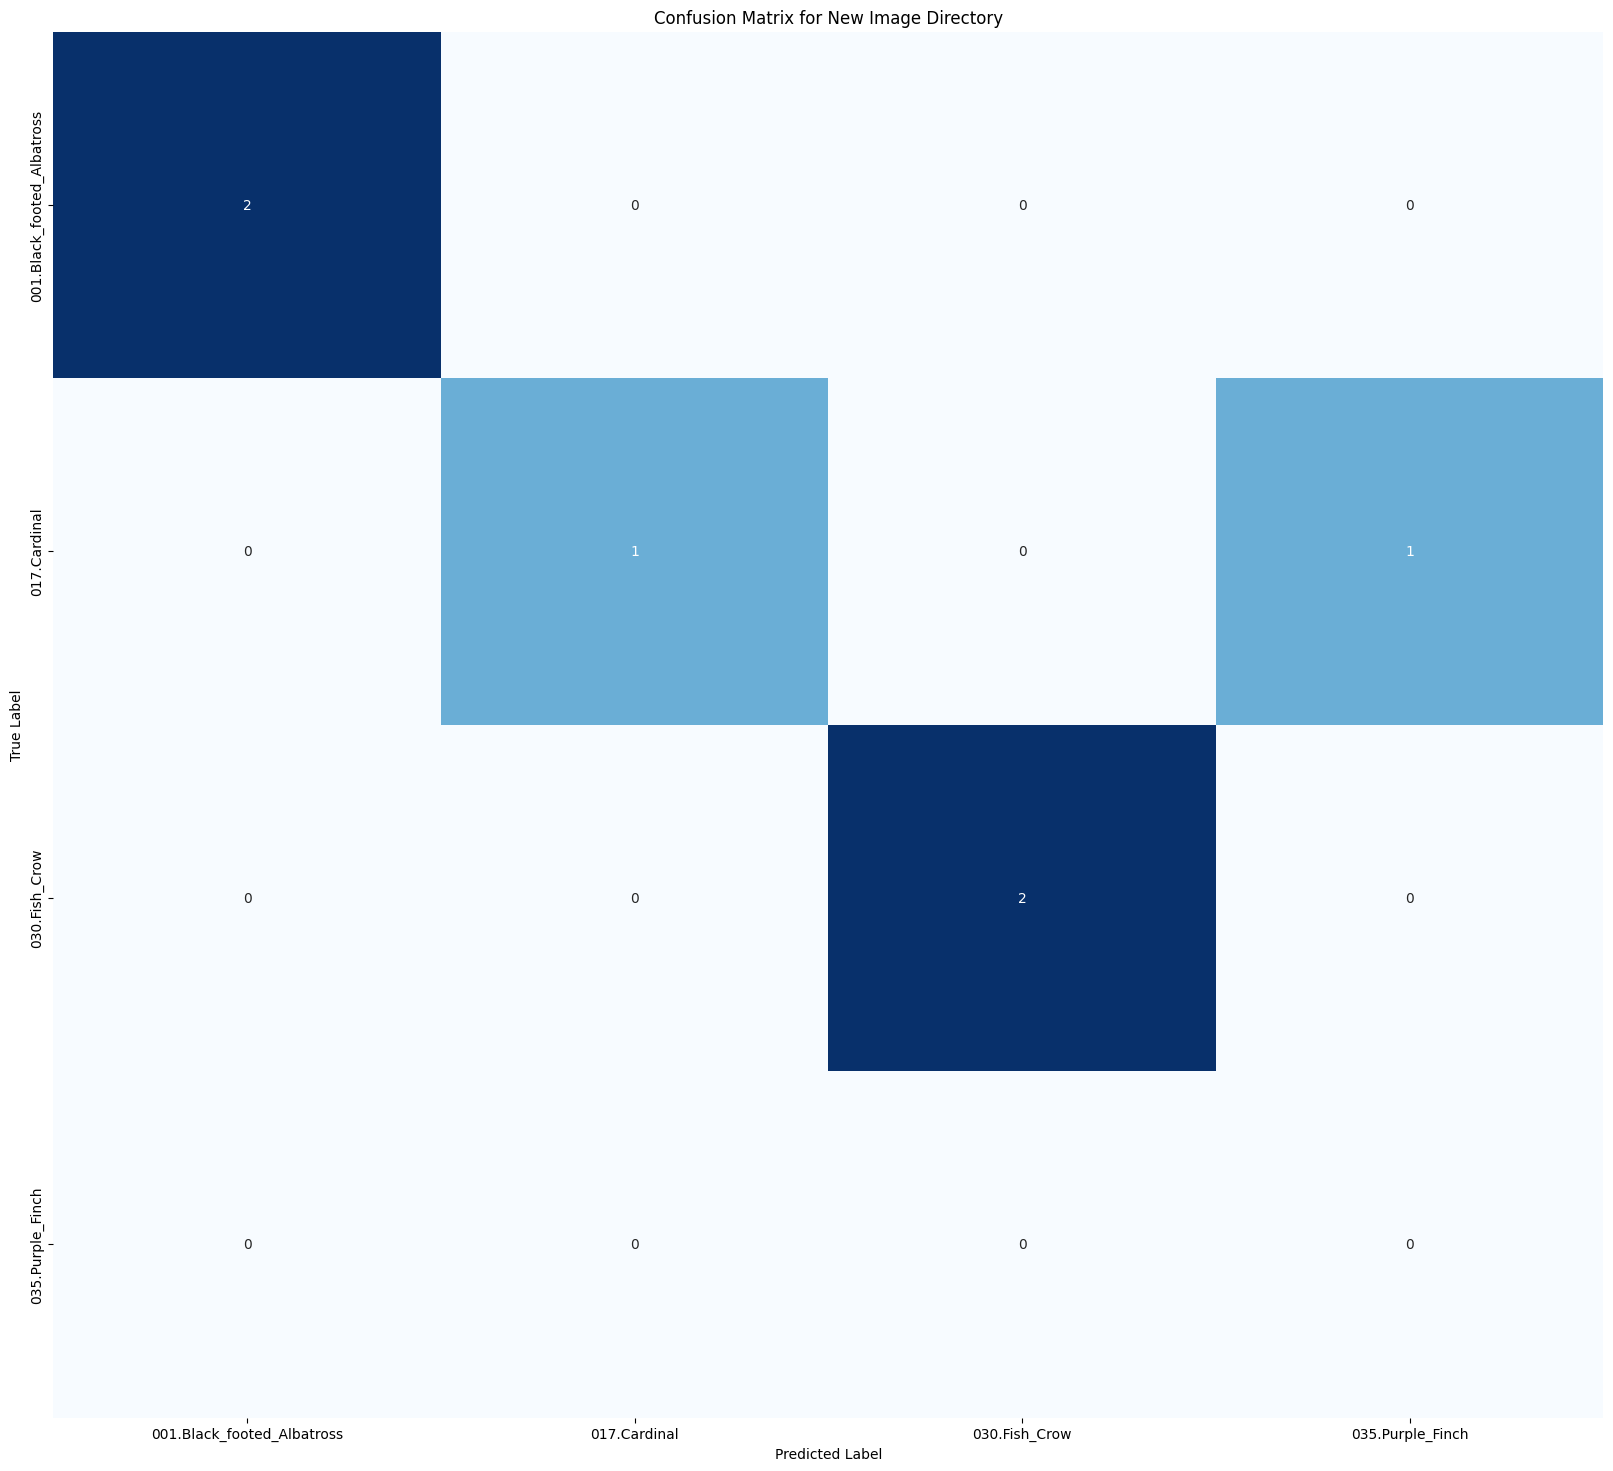

In [12]:
# 1. Evaluate the model on new_img_ds_batched
loss, accuracy = model.evaluate(new_img_ds_batched)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# 2. Make predictions on the new dataset
predictions = model.predict(new_img_ds_batched)
y_pred = np.argmax(predictions, axis=1)

# 3. y_true_global_idx already contains the true labels in integer format
y_true = y_true_global_idx_array

# Get all unique labels present in both y_true and y_pred
all_involved_labels = np.unique(np.concatenate((y_true, y_pred)))

# Create a target_names list that only includes the names of the involved classes
report_class_names = [class_list[idx] for idx in all_involved_labels]

# 4. Generate classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=all_involved_labels, target_names=report_class_names, zero_division=0))

# 5. Generate and plot confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=all_involved_labels)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=report_class_names, yticklabels=report_class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for New Image Directory")
plt.show()

# Model 2: Classification Neural Network from Scratch

Used the design from: https://keras.io/examples/vision/image_classification_from_scratch/

## Build Model

In [ ]:
def make_model(input_shape, num_classes):
  inputs = keras.Input(shape=input_shape)

  x = keras.layers.Rescaling(1.0/255)(inputs)
  x = keras.layers.Conv2D(128, 3, strides=2, padding="same")(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation("relu")(x)

  previous_block = x

  for size in [256, 512, 728]:
    x = keras.layers.Activation("relu")(x)
    x = keras.layers.SeparableConv2D(size, 3, padding="same")(x)
    x = keras.layers.BatchNormalization()(x)

    x = keras.layers.Activation("relu")(x)
    x = keras.layers.SeparableConv2D(size, 3, padding="same")(x)
    x = keras.layers.BatchNormalization()(x)

    x = keras.layers.MaxPooling2D(3, strides=2, padding="same")(x)

    residual = keras.layers.Conv2D(size, 1, strides=2, padding="same")(
        previous_block
    )
    x = keras.layers.add([x, residual])
    previous_block = x

  x = keras.layers.SeparableConv2D(1024, 3, padding="same")(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation("relu")(x)

  x = keras.layers.GlobalAveragePooling2D()(x)
  x = keras.layers.Dropout(0.5)(x)
  outputs = keras.layers.Dense(num_classes, activation=None)(x)
  return keras.Model(inputs, outputs)

In [ ]:
scratch_model = make_model(input_shape=(150,150,3), num_classes=200)
scratch_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_12        │ (None, 150, 150,  │          0 │ input_layer_15[0… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 75, 75,    │      3,584 │ rescaling_12[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        512 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 75, 75,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (None, 75, 75,    │          0 │ activation_24[0]… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_21 │ (None, 75, 75,    │     34,176 │ activation_25[0]… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_26       │ (None, 75, 75,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_22 │ (None, 75, 75,    │     68,096 │ activation_26[0]… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 38, 38,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 38, 38,    │     33,024 │ activation_24[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 38, 38,    │          0 │ max_pooling2d_9[… │
│                     │ 256)              │            │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 38, 38,    │          0 │ add_9[0][0]       │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_23 │ (None, 38, 38,    │    133,888 │ activation_27[0]… │
│ (SeparableConv2D)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 38, 38,    │      2,048 │ separable_conv2d

 Total params: 2,935,040 (11.20 MB)

 Trainable params: 2,926,752 (11.16 MB)

 Non-trainable params: 8,288 (32.38 KB)

## Train Model

In [ ]:
epochs = 50

callbacks = [keras.callbacks.ModelCheckpoint("model2_save_at_{epoch}.keras")]

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.CategoricalAccuracy()]
)

model.fit(train_ds, epochs=epochs, callbacks=callbacks, validation_data=validation_ds)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - categorical_accuracy: 0.9929 - loss: 0.0755 - val_categorical_accuracy: 0.5559 - val_loss: 1.6808
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 253ms/step - categorical_accuracy: 0.9920 - loss: 0.0671 - val_categorical_accuracy: 0.5559 - val_loss: 1.6800
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 270ms/step - categorical_accuracy: 0.9938 - loss: 0.0649 - val_categorical_accuracy: 0.5509 - val_loss: 1.6784
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 268ms/step - categorical_accuracy: 0.9943 - loss: 0.0585 - val_categorical_accuracy: 0.5593 - val_loss: 1.6783
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 252ms/step - categorical_accuracy: 0.9946 - loss: 0.0548 - val_categorical_accuracy: 0.5526 - val_loss: 1.6821
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 262ms/step - categorical_accuracy: 0.9954 - loss: 0.0557 - val_categorical_accuracy: 0.5593 - val_loss: 1.6887
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 259ms/step - categorical_accuracy: 0.9965 

## Evaluate Model

91/91 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - categorical_accuracy: 0.6132 - loss: 1.5862
Test Loss: 1.6228
Test Accuracy: 0.6061
91/91 ━━━━━━━━━━━━━━━━━━━━ 22s 154ms/step

Classification Report:
              precision    recall  f1-score   support

     class_0       0.69      0.81      0.75        27
     class_1       0.63      0.83      0.72        29
     class_2       0.70      0.55      0.62        29
     class_3       0.88      0.73      0.80        30
     class_4       0.81      0.74      0.77        23
     class_5       0.94      0.58      0.71        26
     class_6       0.72      0.92      0.81        25
     class_7       0.68      0.68      0.68        22
     class_8       0.50      0.47      0.48        30
     class_9       0.93      0.84      0.88        31
    class_10       0.48      0.47      0.48        32
    class_11       0.96      0.89      0.92        27
    class_12       0.86      0.92      0.89        26
    class_13       0.62      0.91      0.73      

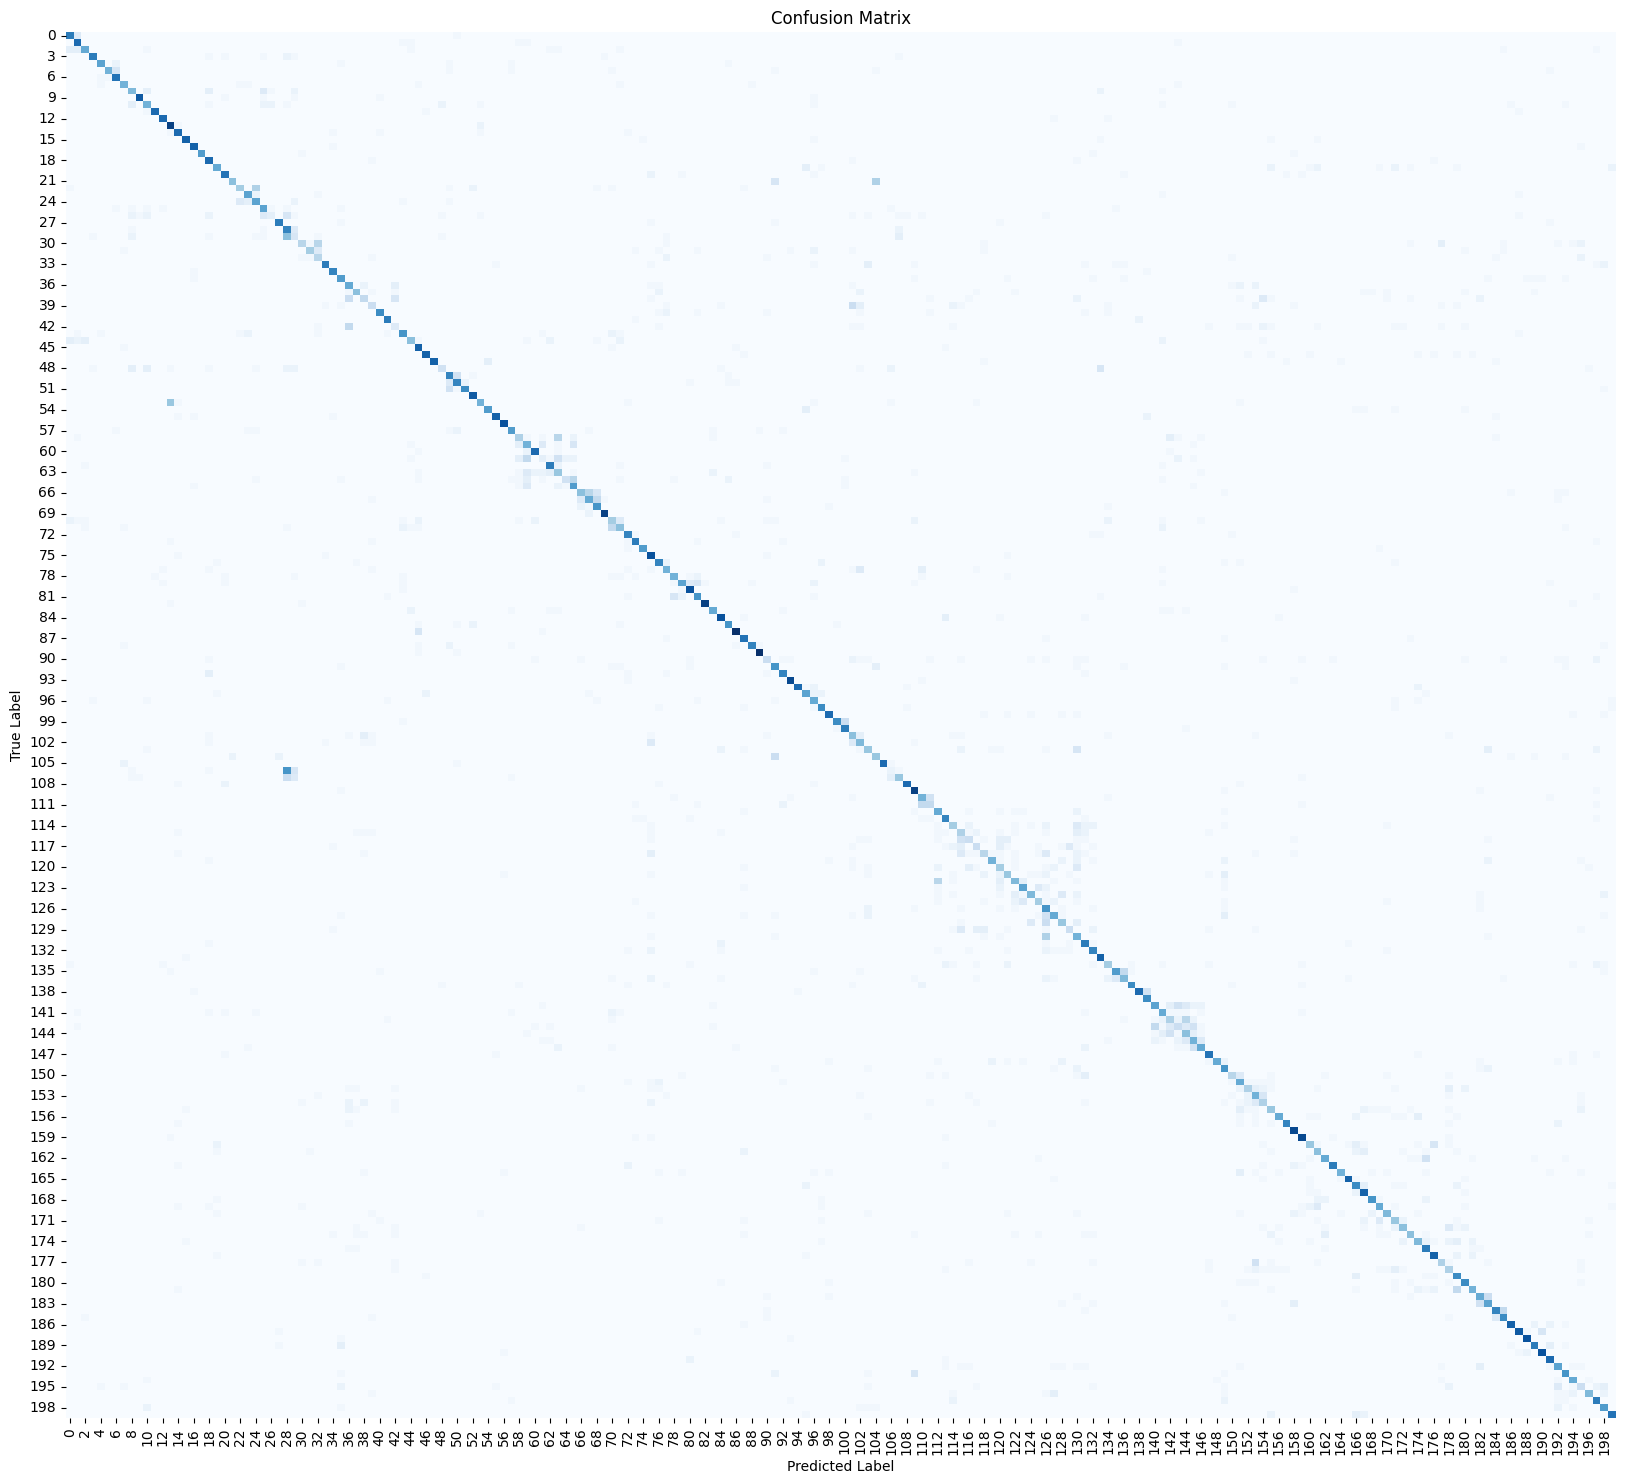

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions on the test dataset
predictions = model.predict(test_ds)
y_pred = np.argmax(predictions, axis=1)

# Extract true labels from the test dataset
y_true = []
for _, labels in test_ds.unbatch():
    y_true.append(np.argmax(labels.numpy()))
y_true = np.array(y_true)

# Generate classification report
class_names = [f"class_{i}" for i in range(200)] # Assuming 200 classes
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Generate and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Test code for demo

In [13]:
import keras
import os
import numpy as np
import tensorflow as tf
from tensorflow import data as tf_data
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the pre-trained model
model = keras.models.load_model("model2_save_at_50.keras")
print("Model 'model2_save_at_50.keras' loaded successfully.")

# 2. Open the file `classes.txt` and read each line to create a list named `class_list`
with open("classes.txt", 'r') as f:
  class_list = [line.strip().split()[1] for line in f] # This is the global list of 200 classes
NUM_CLASSES = len(class_list) # Should be 200
print(f"Loaded {NUM_CLASSES} classes from classes.txt.")

# 3. Prompt the user for the directory name containing the images for prediction
new_image_directory_input = input("Please provide the file name directory containing the images for prediction: ")

# 4. Construct the full path to the new image directory
new_image_directory = os.path.join("/content", new_image_directory_input)

# 5. Check if a zipped file exists and unzip, or if the directory already exists
zips_path = f"{new_image_directory}.zip"
if os.path.exists(zips_path):
  print(f"Zipped file found: {zips_path}. Unzipping...")
  !unzip "{zips_path}"
  print(f"Image directory set to: {new_image_directory}")
elif os.path.exists(new_image_directory):
  print(f"Image directory already unzipped: {new_image_directory}")
else:
  raise ValueError("Image directory or zip file not found")

# 6. Load the raw image dataset
new_img_ds_raw = keras.utils.image_dataset_from_directory(
    directory=new_image_directory,
    labels="inferred",
    label_mode="categorical",
    batch_size=None
)
print(f"Raw image dataset loaded from {new_image_directory}.")

Model 'model2_save_at_50.keras' loaded successfully.
Loaded 200 classes from classes.txt.
Please provide the file name directory containing the images for prediction: Demo_test_images
Zipped file found: /content/Demo_test_images.zip. Unzipping...
Archive:  /content/Demo_test_images.zip
replace Demo_test_images/001.Black_footed_Albatross/Black_Footed_Albatross_0033_796086.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Image directory set to: /content/Demo_test_images
Found 6 files belonging to 3 classes.
Raw image dataset loaded from /content/Demo_test_images.


In [14]:
# Redefine resize_img layer to ensure it's available in this scope
resize_img = keras.layers.Resizing(150, 150)

# 1. Create a dictionary named `global_class_name_to_idx`
global_class_name_to_idx = {name: i for i, name in enumerate(class_list)}
print("Global class name to index mapping created.")

# 2. Initialize two empty Python lists
resized_images = []
y_true_global_idx = []

# 3. Get the list of class names inferred from the new_img_ds_raw dataset
inferred_class_names = new_img_ds_raw.class_names
print(f"Inferred class names from dataset: {inferred_class_names}")

# 4. Iterate through each image, label pair in new_img_ds_raw
for image, label in new_img_ds_raw:
    # 5. Resize the image and append it to the resized_images list
    resized_images.append(resize_img(image).numpy())

    # 6. For each label, find its integer index
    inferred_idx = np.argmax(label.numpy())

    # 7. Use this index to get the inferred_class_name
    inferred_name = inferred_class_names[inferred_idx]

    # 8. Look up the inferred_class_name in the global_class_name_to_idx dictionary
    global_idx = global_class_name_to_idx[inferred_name]

    # 9. Append this global integer index to the y_true_global_idx list
    y_true_global_idx.append(global_idx)

print(f"Processed {len(resized_images)} images. Resized images and global true labels collected.")
print(f"Number of resized images: {len(resized_images)}")
print(f"Number of global true labels: {len(y_true_global_idx)}")

Global class name to index mapping created.
Inferred class names from dataset: ['001.Black_footed_Albatross', '017.Cardinal', '030.Fish_Crow']
Processed 6 images. Resized images and global true labels collected.
Number of resized images: 6
Number of global true labels: 6


In [15]:
# Convert lists to NumPy arrays
images_array = np.array(resized_images)
y_true_global_idx_array = np.array(y_true_global_idx)

print(f"Shape of images_array: {images_array.shape}")
print(f"Shape of y_true_global_idx_array: {y_true_global_idx_array.shape}")

# One-hot encode the global integer labels
y_true_one_hot = tf.one_hot(y_true_global_idx_array, depth=NUM_CLASSES)

print(f"Shape of y_true_one_hot: {y_true_one_hot.shape}")

# Create a new tf.data.Dataset
new_img_ds = tf.data.Dataset.from_tensor_slices((images_array, y_true_one_hot))

# Batch, prefetch, and cache the new dataset for evaluation
BATCH_SIZE = 64 # Using the same batch size as earlier cells
new_img_ds_batched = new_img_ds.batch(BATCH_SIZE).prefetch(tf_data.AUTOTUNE).cache()

print(f"Created batched dataset with {new_img_ds_batched.cardinality().numpy()} batches.")

Shape of images_array: (6, 150, 150, 3)
Shape of y_true_global_idx_array: (6,)
Shape of y_true_one_hot: (6, 200)
Created batched dataset with 1 batches.


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - categorical_accuracy: 0.8333 - loss: 0.3860
Test Loss: 0.3860
Test Accuracy: 0.8333
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

Classification Report:
                            precision    recall  f1-score   support

001.Black_footed_Albatross       1.00      1.00      1.00         2
              017.Cardinal       1.00      0.50      0.67         2
             030.Fish_Crow       1.00      1.00      1.00         2
          035.Purple_Finch       0.00      0.00      0.00         0

                  accuracy                           0.83         6
                 macro avg       0.75      0.62      0.67         6
              weighted avg       1.00      0.83      0.89         6



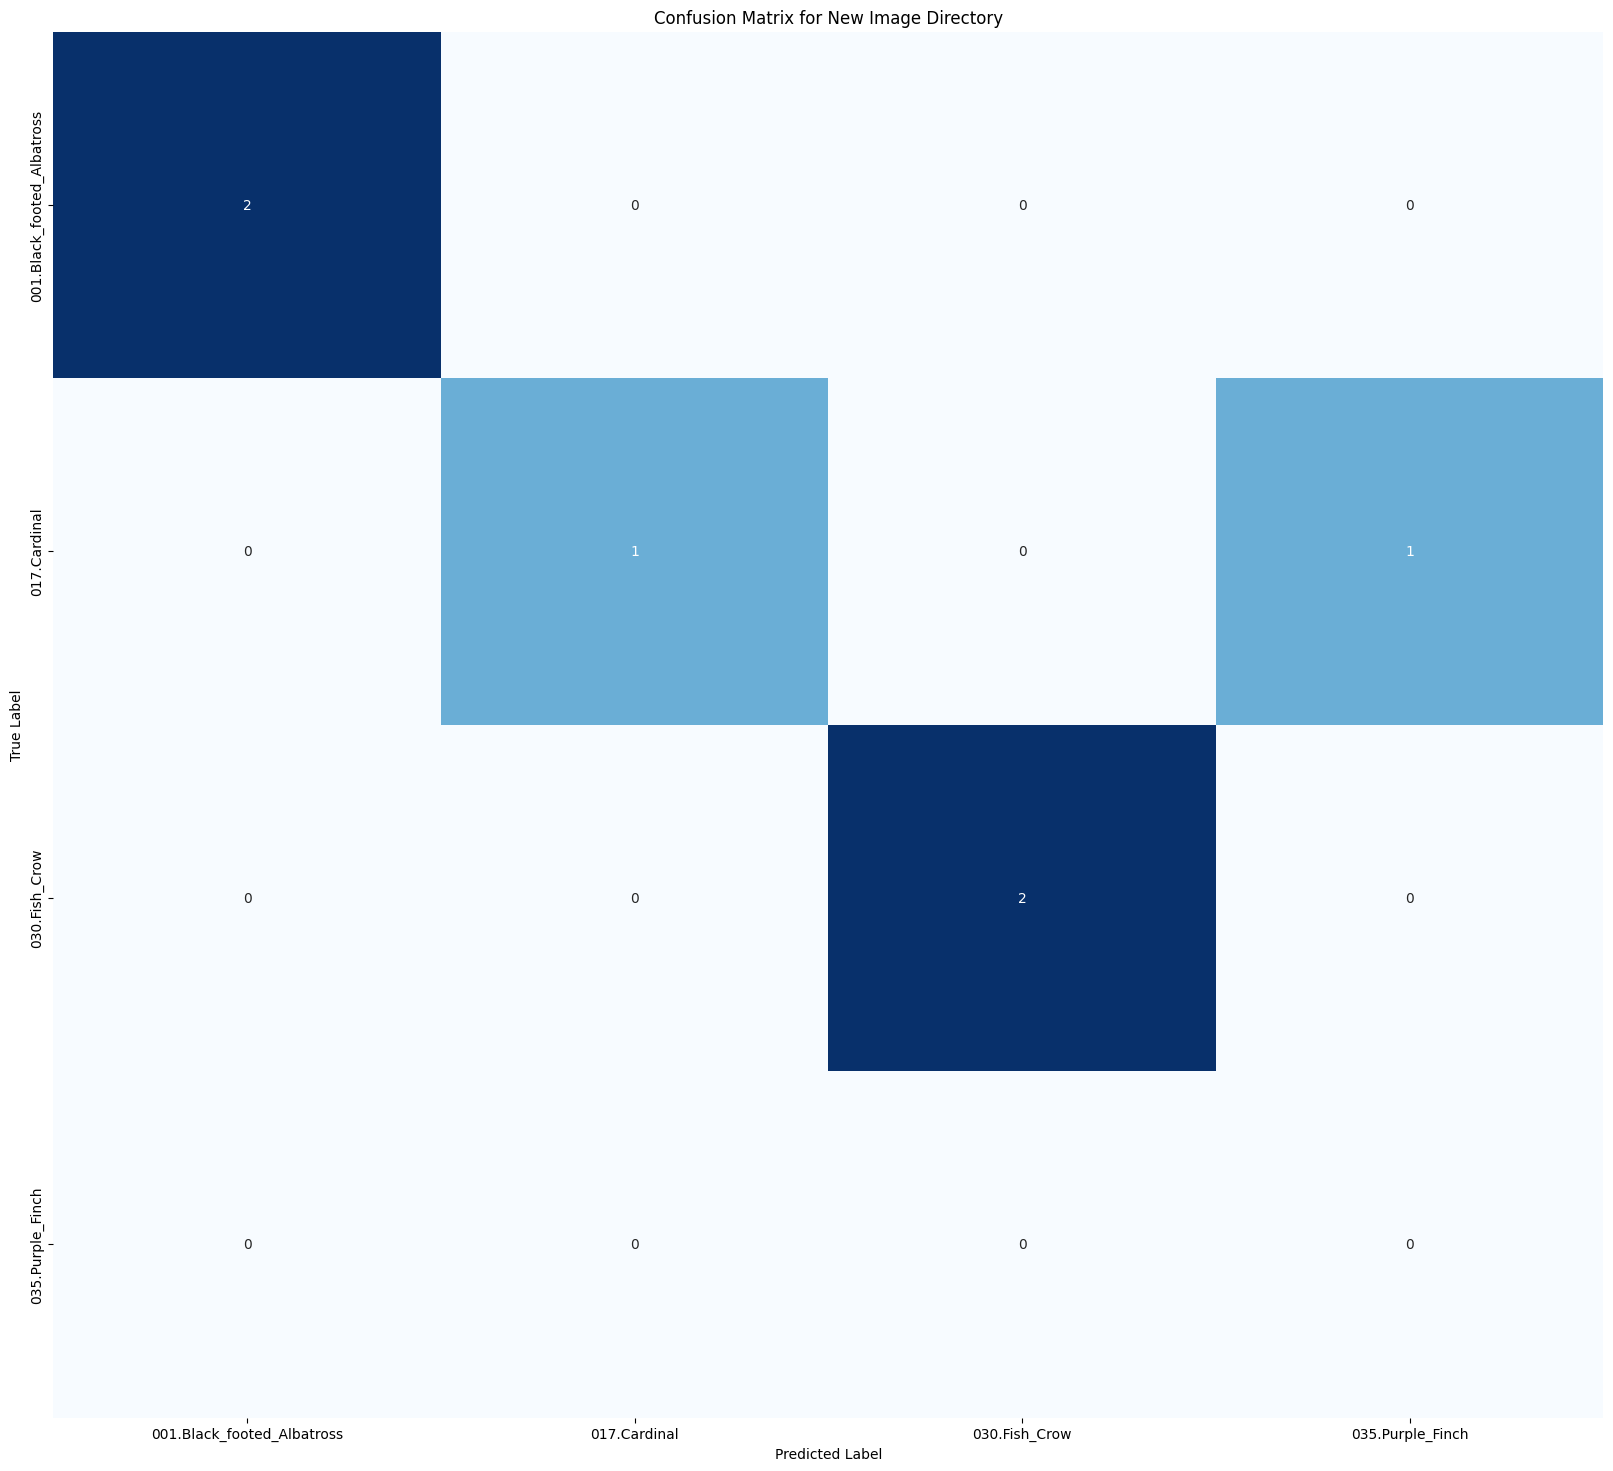

In [16]:
# 1. Evaluate the model on new_img_ds_batched
loss, accuracy = model.evaluate(new_img_ds_batched)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# 2. Make predictions on the new dataset
predictions = model.predict(new_img_ds_batched)
y_pred = np.argmax(predictions, axis=1)

# 3. y_true_global_idx already contains the true labels in integer format
y_true = y_true_global_idx_array

# Get all unique labels present in both y_true and y_pred
all_involved_labels = np.unique(np.concatenate((y_true, y_pred)))

# Create a target_names list that only includes the names of the involved classes
report_class_names = [class_list[idx] for idx in all_involved_labels]

# 4. Generate classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=all_involved_labels, target_names=report_class_names, zero_division=0))

# 5. Generate and plot confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=all_involved_labels)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=report_class_names, yticklabels=report_class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for New Image Directory")
plt.show()

# Mini Report on Model 1 & 2

## Model 1

The project started with globally loading all the data from the set we were initially given. The data had a few helpful plaintext files on the metadata, which could be used to load the data, the classes and split on which images are training and test. We call it global because both models would share a similar level of pre-processing and loading, this envolved:
- Loading the files and splitting the repositries into test and training sets, keras has a useful feature that allows the images to be loaded from a directory and could infer the class labels automatically since the input directory structure matched the one provided. For the training, a 9:1 split of training to validation was done automatically through keras using a generic random seed that helps re-producability
- The images resized to be consistent and so that all images that are loaded into the neurel network are all the same size.
- Images augmented, this was our first hyperparameter for model improvements, as each augmentation fed into the network allows the same image to be fed into the model at different perspectives. This increases overall accuracy of the model. The number of random augmented changes made to each image was set to 3, as we did not want to be overly agressive with data augmentation, but wanted the model to better fit using altering perspectives.

For the rest of the hyperparameters, we performed a number of experiments to determine the best combinations for each tests models. This looked like this:
- InceptionV3, EfficientNetB0, EfficientNetB4, EfficientNetB7, EfficientNetV2B0, EfficientNetV2B3
  * Dropout & Learning Rate:
    * 0.2, 0.3, 0.5 & 1e-5, 1e-6, 1e-8

We performed transfer learning with EfficientNetV2B3, freezing the model with weights pre-trained using imagenet with a base model of just Dropout and global average pooling for 2D data.  

They all performed around the same except InceptionV3 which would not increase its validation accuracy about ~0.3. The rest of them where between ~0.45 and ~0.55. In this case, we decided EfficientNetV2B3 at 1e-5 learning rate and 0.5 dropout. This created a validation accuracy of around ~0.54.

This produced an average weighted result of:
- precision = 0.61      
- recall = 0.59      
- F1-Score = 0.59


## Model 2

Model 2 had the same pre-processing setps and used the same hyperparameters as model since the task to complete was very similar and the design for the model was heavily inspired by keras documentation.

The main points of this model where the design desicions made to create the network:
- Firstly, the images where rescaled into input layer as per the pre-processing step, they are then fed through the first convolution at a fairly low resolution. This is then fed through normalisation and activation to add some non-linearity to the patterns matching.
- Secondly, the model iterates over larger and larger resolutions and adding the relevent convolutions, max pooling and activations so the model can iterativley filter more and more fine tuned patterns.
- Finally, a last set convolutions is applied that is connected to a final pool and a dropout is applied. The result of all of these are condensed down onto a dense layers of size 200 as that is the number of classes to predict.

Using the same hyperparameters as before the weighted average results are as follows:
- precision = 0.62
  recall = 0.61
  F1-Score = 0.60